In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [23]:
class BatsmanState(TypedDict):
    runs: int
    balls:int
    fours:int
    sixes:int
    
    sr:float
    bpb:float
    bp:float
    summary=str


In [24]:
def calculate_sr(state:BatsmanState):
    sr= (state['runs']/state['balls'])*100
    
    # state['sr']=sr
    return {'sr':sr}

def calculate_bpb(state:BatsmanState):
    bpb= state['balls']/(state['fours']+state['sixes'])
    
    # state['bpb']=bpb
    return {'bpb':bpb}

def calculate_bp(state:BatsmanState):
    br= state['fours']*4+state['sixes']*6
    bp= (br/state['runs'])*100
    
    # state['bp']=bp
    return {'bp':bp}
    
def summary(state:BatsmanState):
    summary= f'''
    Strike Rate: {state['sr']:.2f} \n
    Balls: {state['balls']}\n
    Fours: {state['fours']}\n
    Sixes: {state['sixes']}\n
    Ball per Boundary: {state['bpb']:.2f}\n
    Boundary Percent: {state['bp']:.2f}%
    '''
    # state['summary']=summary
    return {'summary':summary}

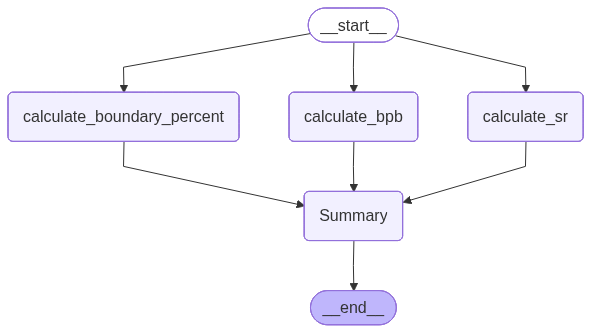

In [25]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary_percent',calculate_bp)
graph.add_node('Summary',summary)

#edges

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')  

graph.add_edge('calculate_sr','Summary')
graph.add_edge('calculate_bpb','Summary')
graph.add_edge('calculate_boundary_percent','Summary')

graph.add_edge('Summary',END)

workflow= graph.compile()
workflow

In [26]:
initial_state={
    'runs':100,
    'balls':60,
    'fours':10,
    'sixes':5
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 60,
 'fours': 10,
 'sixes': 5,
 'sr': 166.66666666666669,
 'bpb': 4.0,
 'bp': 70.0}